<a href="https://colab.research.google.com/github/ywchanna2001/Protein_Conformational_Ensembles_Prediction/blob/dev/modules/MSA-Generation/MSA-Generation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
#@title Input protein sequence(s)
from google.colab import files
import os
import re
import hashlib
import random

from sys import version_info
python_version = f"{version_info.major}.{version_info.minor}"

def add_hash(x,y):
  return x+"_"+hashlib.sha1(y.encode()).hexdigest()[:5]

query_sequence = 'MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSDYNIQKESTLHLVLRLRGG' #@param {type:"string"}
#@markdown  - Use `:` to specify inter-protein chainbreaks for **modeling complexes** (supports homo- and hetro-oligomers). For example **PI...SK:PI...SK** for a homodimer
jobname = 'Test1' #@param {type:"string"}
# number of models to use
num_relax = 5 #@param [0, 1, 5] {type:"raw"}
#@markdown - specify how many of the top ranked structures to relax using amber
template_mode = "none" #@param ["none", "pdb100","custom"]
#@markdown - `none` = no template information is used. `pdb100` = detect templates in pdb100 (see [notes](#pdb100)). `custom` - upload and search own templates (PDB or mmCIF format, see [notes](#custom_templates))

use_amber = num_relax > 0

# remove whitespaces
query_sequence = "".join(query_sequence.split())

basejobname = "".join(jobname.split())
basejobname = re.sub(r'\W+', '', basejobname)
jobname = add_hash(basejobname, query_sequence)

# check if directory with jobname exists
def check(folder):
  if os.path.exists(folder):
    return False
  else:
    return True
if not check(jobname):
  n = 0
  while not check(f"{jobname}_{n}"): n += 1
  jobname = f"{jobname}_{n}"

# make directory to save results
os.makedirs(jobname, exist_ok=True)

# save queries
queries_path = os.path.join(jobname, f"{jobname}.csv")
with open(queries_path, "w") as text_file:
  text_file.write(f"id,sequence\n{jobname},{query_sequence}")

if template_mode == "pdb100":
  use_templates = True
  custom_template_path = None
elif template_mode == "custom":
  custom_template_path = os.path.join(jobname,f"template")
  os.makedirs(custom_template_path, exist_ok=True)
  uploaded = files.upload()
  use_templates = True
  for fn in uploaded.keys():
    os.rename(fn,os.path.join(custom_template_path,fn))
else:
  custom_template_path = None
  use_templates = False

print("jobname",jobname)
print("sequence",query_sequence)
print("length",len(query_sequence.replace(":","")))

jobname Test1_7686d
sequence MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSDYNIQKESTLHLVLRLRGG
length 76


In [24]:
#@title Install dependencies
%%time
import os
USE_AMBER = use_amber
USE_TEMPLATES = use_templates
PYTHON_VERSION = python_version

if not os.path.isfile("COLABFOLD_READY"):
  print("installing colabfold...")
  os.system("pip install -q --no-warn-conflicts 'colabfold[alphafold-minus-jax] @ git+https://github.com/sokrypton/ColabFold'")
  if os.environ.get('TPU_NAME', False) != False:
    os.system("pip uninstall -y jax jaxlib")
    os.system("pip install --no-warn-conflicts --upgrade dm-haiku==0.0.10 'jax[cuda12_pip]'==0.3.25 -f https://storage.googleapis.com/jax-releases/jax_cuda_releases.html")
  os.system("ln -s /usr/local/lib/python3.*/dist-packages/colabfold colabfold")
  os.system("ln -s /usr/local/lib/python3.*/dist-packages/alphafold alphafold")
  # hack to fix TF crash
  os.system("rm -f /usr/local/lib/python3.*/dist-packages/tensorflow/core/kernels/libtfkernel_sobol_op.so")
  os.system("touch COLABFOLD_READY")

if USE_AMBER or USE_TEMPLATES:
  if not os.path.isfile("CONDA_READY"):
    print("installing conda...")
    os.system("wget -qnc https://github.com/conda-forge/miniforge/releases/latest/download/Miniforge3-Linux-x86_64.sh")
    os.system("bash Miniforge3-Linux-x86_64.sh -bfp /usr/local")
    os.system("mamba config --set auto_update_conda false")
    os.system("touch CONDA_READY")

if USE_TEMPLATES and not os.path.isfile("HH_READY") and USE_AMBER and not os.path.isfile("AMBER_READY"):
  print("installing hhsuite and amber...")
  os.system(f"mamba install -y -c conda-forge -c bioconda kalign2=2.04 hhsuite=3.3.0 openmm=8.2.0 python='{PYTHON_VERSION}' pdbfixer")
  os.system("touch HH_READY")
  os.system("touch AMBER_READY")
else:
  if USE_TEMPLATES and not os.path.isfile("HH_READY"):
    print("installing hhsuite...")
    os.system(f"mamba install -y -c conda-forge -c bioconda kalign2=2.04 hhsuite=3.3.0 python='{PYTHON_VERSION}'")
    os.system("touch HH_READY")
  if USE_AMBER and not os.path.isfile("AMBER_READY"):
    print("installing amber...")
    os.system(f"mamba install -y -c conda-forge openmm=8.2.0 python='{PYTHON_VERSION}' pdbfixer")
    os.system("touch AMBER_READY")

CPU times: user 393 µs, sys: 0 ns, total: 393 µs
Wall time: 322 µs


In [25]:
#@markdown ### MSA options (custom MSA upload, single sequence, pairing mode)
msa_mode = "mmseqs2_uniref_env" #@param ["mmseqs2_uniref_env", "mmseqs2_uniref","single_sequence","custom"]
pair_mode = "unpaired_paired" #@param ["unpaired_paired","paired","unpaired"] {type:"string"}
#@markdown - "unpaired_paired" = pair sequences from same species + unpaired MSA, "unpaired" = seperate MSA for each chain, "paired" - only use paired sequences.

# decide which a3m to use
if "mmseqs2" in msa_mode:
  a3m_file = os.path.join(jobname,f"{jobname}.a3m")

elif msa_mode == "custom":
  a3m_file = os.path.join(jobname,f"{jobname}.custom.a3m")
  if not os.path.isfile(a3m_file):
    custom_msa_dict = files.upload()
    custom_msa = list(custom_msa_dict.keys())[0]
    header = 0
    import fileinput
    for line in fileinput.FileInput(custom_msa,inplace=1):
      if line.startswith(">"):
         header = header + 1
      if not line.rstrip():
        continue
      if line.startswith(">") == False and header == 1:
         query_sequence = line.rstrip()
      print(line, end='')

    os.rename(custom_msa, a3m_file)
    queries_path=a3m_file
    print(f"moving {custom_msa} to {a3m_file}")

else:
  a3m_file = os.path.join(jobname,f"{jobname}.single_sequence.a3m")
  with open(a3m_file, "w") as text_file:
    text_file.write(">1\n%s" % query_sequence)

In [26]:
# --- MODULE 1: ROBUST MSA GENERATION (Fixed) ---
import os
import time
from colabfold.colabfold import run_mmseqs2

search_mode = "mmseqs2_uniref_env"
use_env = "env" in search_mode

print(f"Target Sequence: {query_sequence[:30]}...")
print(f"Job Name: {jobname}")

# FIX 1: Delete any stale cached .a3m file so the API is actually called
a3m_cache = os.path.join(jobname, f"{jobname}.a3m")
if os.path.isfile(a3m_cache):
    os.remove(a3m_cache)
    print("Removed cached .a3m — forcing fresh API search...")

print("Status: Contacting MMseqs2 server (this can take 1–3 minutes)...")

try:
    # FIX 2: Capture result correctly — run_mmseqs2 returns a LIST of a3m content strings
    result = run_mmseqs2(
        x=query_sequence,
        prefix=jobname,
        use_env=use_env,
        use_filter=True,           #  FIX 3: Required for proper hit filtering
        use_pairing=False,
    )

    #  FIX 4: Flatten the result into individual lines correctly
    # result is a list of strings; each string can be a full a3m block
    if isinstance(result, list):
        a3m_lines = "\n".join(result).splitlines(keepends=True)
    else:
        a3m_lines = result.splitlines(keepends=True)

    #  FIX 5: Count sequences properly (lines starting with '>')
    num_seqs = sum(1 for line in a3m_lines if line.startswith(">"))

    print(f"Total lines in result: {len(a3m_lines)}")
    print(f"Sequences found (headers): {num_seqs}")

    if num_seqs <= 1:
        print("❌ ERROR: Server returned 0 hits.")
        print("Debugging info:")
        print("".join(a3m_lines[:10]))  # Show first 10 lines for diagnosis
        print("\nPossible causes:")
        print("  - MMseqs2 API server is down or overloaded (try again in 1 min)")
        print("  - Sequence too short/non-standard for database hits")
        print("  - Network issue in Colab (try Runtime > Restart and run all)")
    else:
        # Save valid MSA
        msa_module_dir = "research_msa_output"
        os.makedirs(msa_module_dir, exist_ok=True)
        msa_file_path = os.path.join(msa_module_dir, f"{jobname}.a3m")

        with open(msa_file_path, "w") as f:
            f.writelines(a3m_lines)

        print(f"✅ SUCCESS: {num_seqs} sequences saved to {msa_file_path}")

except Exception as e:
    print(f"❌ SERVER ERROR: {e}")
    import traceback
    traceback.print_exc()

Target Sequence: MQIFVKTLTGKTITLEVEPSDTIENVKAKI...
Job Name: Test1_7686d
Status: Contacting MMseqs2 server (this can take 1–3 minutes)...


COMPLETE: 100%|██████████| 150/150 [elapsed: 00:02 remaining: 00:00]

Total lines in result: 43154
Sequences found (headers): 21577
✅ SUCCESS: 21577 sequences saved to research_msa_output/Test1_7686d.a3m


Query length  : 76
Total sequences: 21577
Plotting 21577 sequences × 76 positions...


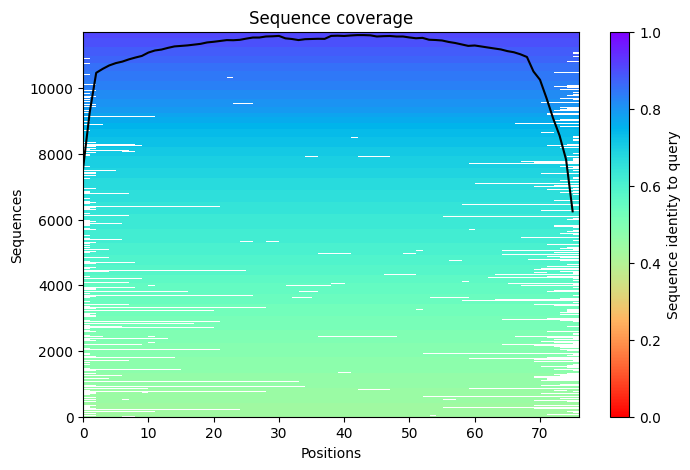

In [27]:
#@title Module 1 Visualization: Authentic ColabFold Plot Style (Fixed)
import numpy as np
import matplotlib.pyplot as plt
from colabfold.plot import plot_msa_v2

def generate_authentic_msa_plot(a3m_lines):
    """
    Replicates the exact behaviour of input_features_callback in the original
    ColabFold run cell, which passes raw input_features directly to plot_msa_v2.
    """

    # ── 1. Parse A3M: keep UPPERCASE only (gaps = '-', insertions = lowercase removed) ──
    sequences = []
    current_seq = []
    for line in a3m_lines:
        line = line.strip()
        if not line:
            continue
        if line.startswith(">"):
            if current_seq:
                sequences.append("".join(current_seq))
            current_seq = []
        else:
            # Keep uppercase residues AND dashes; drop lowercase insertions
            current_seq.append("".join(c if (c.isupper() or c == "-") else "" for c in line))
    if current_seq:
        sequences.append("".join(current_seq))

    if not sequences:
        print("❌ No sequences found in a3m_lines.")
        return

    query_len = len(sequences[0])
    print(f"Query length  : {query_len}")
    print(f"Total sequences: {len(sequences)}")

    # ── 2. Build integer matrix  ──────────────────────────────────────────────
    #   Amino-acid alphabet used by ColabFold's plot_msa_v2:
    #   residue index 20 = gap/unknown  → rendered as NaN (white) by the plotter
    map_str = "ARNDCQEGHILKMFPSTWYV"
    res_map = {c: i for i, c in enumerate(map_str)}
    GAP_IDX = 21   # value for '-' or any unknown character

    msa_list = []
    for seq in sequences:
        row = []
        for c in seq[:query_len]:         # truncate if longer than query
            row.append(res_map.get(c.upper(), GAP_IDX))
        # ✅ KEY FIX: do NOT pad — leave shorter sequences as-is;
        #            pad with GAP_IDX only to keep a rectangular matrix
        if len(row) < query_len:
            row += [GAP_IDX] * (query_len - len(row))
        msa_list.append(row)

    msa_arr = np.array(msa_list, dtype=np.int32)

    # ── 3. Sort by sequence identity to query (creates colour gradient) ───────
    query_row = msa_arr[0]
    # Only count positions where the query itself is not a gap
    query_positions = query_row != GAP_IDX
    if query_positions.sum() > 0:
        identity = np.sum(
            (msa_arr[:, query_positions] == query_row[query_positions]),
            axis=1
        ) / query_positions.sum()
    else:
        identity = np.zeros(len(msa_arr))

    sorted_idx = np.argsort(identity)[::-1]   # highest identity first
    msa_arr    = msa_arr[sorted_idx]
    identity   = identity[sorted_idx]

    # ── 4. Build input_features dict exactly as ColabFold's pipeline does ─────
    #   plot_msa_v2 needs:
    #     "msa"             – int32 array  (N_seq × N_res)
    #     "num_alignments"  – int32 array  (N_res,)  = number of non-gap seqs per column
    #     "sequence"        – optional; the query sequence as a list of residue strings

    # num_alignments = per-column count of sequences that are NOT a gap
    num_alignments = np.sum(msa_arr != GAP_IDX, axis=0).astype(np.int32)

    input_features = {
        "msa":            msa_arr,
        "num_alignments": num_alignments,
    }

    # ── 5. Plot ───────────────────────────────────────────────────────────────
    print(f"Plotting {len(msa_arr)} sequences × {query_len} positions...")
    try:
        plot_msa_v2(input_features)
        plt.show()
    except Exception as e:
        print(f"plot_msa_v2 error: {e}")
        # ── Faithful fallback that still shows gaps and coverage curve ────────
        fig, ax = plt.subplots(figsize=(10, 4))

        # Replace GAP_IDX with NaN so gaps render white
        display = msa_arr.astype(float)
        display[display == GAP_IDX] = np.nan

        ax.imshow(display, aspect="auto", cmap="rainbow_r",
                  vmin=0, vmax=20, interpolation="nearest")
        ax.set_xlabel("Positions")
        ax.set_ylabel("Sequences")
        ax.set_title("Sequence coverage")

        # Draw the coverage curve (black line) — same as original
        ax2 = ax.twinx()
        ax2.plot(num_alignments, color="black", linewidth=1.5)
        ax2.set_ylabel("Coverage")
        ax2.set_ylim(0, len(msa_arr))

        plt.tight_layout()
        plt.show()

# ── Run ───────────────────────────────────────────────────────────────────────
if 'a3m_lines' in locals():
    generate_authentic_msa_plot(a3m_lines)
else:
    print("❌ 'a3m_lines' not found — run the MSA Generation cell first.")